# Data Preprocessing
Cleaning and preparing the dataset for modeling.

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from src.preprocessing import load_data, preprocess, split_and_scale

sns.set_theme(style='whitegrid')

In [2]:
df = load_data('../dataset/Telco_customer_churn.xlsx')
print('Raw shape:', df.shape)

Raw shape: (7043, 33)


## Drop Irrelevant / Leaky Columns

In [3]:
df = preprocess(df)
print('After preprocessing:', df.shape)
print(df.dtypes)

After preprocessing: (7043, 27)
Gender                                        int64
Senior Citizen                                int64
Partner                                       int64
Dependents                                    int64
Tenure Months                                 int64
Phone Service                                 int64
Multiple Lines                                int64
Online Security                               int64
Online Backup                                 int64
Device Protection                             int64
Tech Support                                  int64
Streaming TV                                  int64
Streaming Movies                              int64
Paperless Billing                             int64
Monthly Charges                             float64
Total Charges                               float64
Churn Value                                   int64
Internet Service_DSL                           bool
Internet Service_Fiber optic    

In [4]:
# make sure there are no missing values left
print('Missing values:', df.isnull().sum().sum())

Missing values: 0


## Feature Distribution Before Scaling

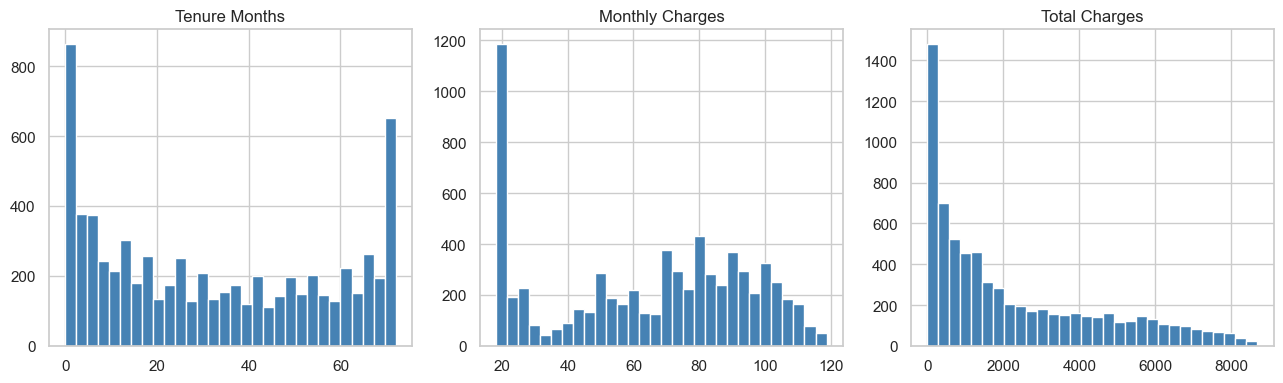

In [5]:
num_cols = ['Tenure Months', 'Monthly Charges', 'Total Charges']

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(col)

plt.tight_layout()
plt.savefig('../outputs/figures/06_before_scaling.png', dpi=150, bbox_inches='tight')
plt.show()

## Train / Test Split and Scaling

In [6]:
X_train, X_test, y_train, y_test, scaler = split_and_scale(df)

print('X_train:', X_train.shape)
print('X_test: ', X_test.shape)
print('Train churn rate:', round(y_train.mean(), 3))
print('Test  churn rate:', round(y_test.mean(), 3))

X_train: (5634, 26)
X_test:  (1409, 26)
Train churn rate: 0.265
Test  churn rate: 0.265


## Feature Correlation with Target

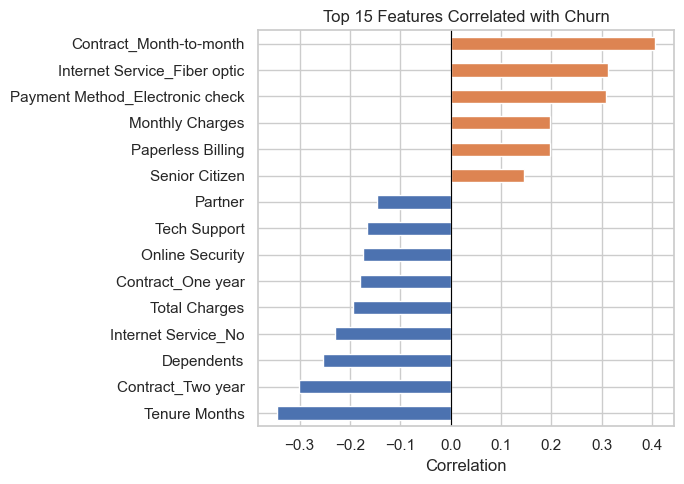

In [7]:
temp = X_train.copy()
temp['Churn Value'] = y_train.values

corr = temp.corr()['Churn Value'].drop('Churn Value').sort_values(key=abs, ascending=False).head(15)

plt.figure(figsize=(7, 5))
corr.sort_values().plot(kind='barh', color=['#DD8452' if v > 0 else '#4C72B0' for v in corr.sort_values()])
plt.title('Top 15 Features Correlated with Churn')
plt.xlabel('Correlation')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('../outputs/figures/07_feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## Save Processed Data

In [8]:
import os
os.makedirs('../outputs', exist_ok=True)

X_train.to_csv('../outputs/X_train.csv', index=False)
X_test.to_csv('../outputs/X_test.csv', index=False)
y_train.to_csv('../outputs/y_train.csv', index=False)
y_test.to_csv('../outputs/y_test.csv', index=False)
joblib.dump(scaler, '../outputs/scaler.pkl')

print('Done.')

Done.
